# SPHEREx spectrophotometry of a transient

Forced photometry on every SPHEREx Level 2 spectral image that covers a transient's position,
using `obsutils.spherex`. The worked example is the TDE **AT2025abcr** (TDE-H-He, z = 0.05,
discovered 2025-10-13), which is **off-nuclear**: the host nucleus sits 9.4 arcsec away, and
there was no point source at the transient position beforehand. At 6.15 arcsec/pixel that is
1.5 pixels, so the two are barely separable and the blending has to be handled explicitly. See
the section on companions below. Nothing else here is specific to this target: change `source`
and `reference_mjd` and rerun.

SPHEREx images the sky through linear variable filters, so a single exposure measures one
wavelength at a given sky position, and the sampled wavelength changes from visit to visit as
the spacecraft repoints. There is no ready-made spectrum to download for a transient: the
spectrum is assembled by measuring the source in many individual spectral images and recording
the wavelength each one happened to sample.

For a one-line version of this whole notebook, see the last section, or run the CLI:

```
spherex-phot AT2025abcr --reference-mjd 60961.28 --deblend --plot
```

Built on IRSA's tutorials: [Introduction to SPHEREx Spectral
Images](https://caltech-ipac.github.io/irsa-tutorials/spherex-intro/), [SPHEREx
cutouts](https://caltech-ipac.github.io/irsa-tutorials/spherex-cutouts/), and the [Source
Discovery Tool](https://caltech-ipac.github.io/irsa-tutorials/spherex-source-discovery-tool-demo/),
whose aperture photometry recipe `obsutils.spherex.photometry` follows.

In [1]:
import logging

import numpy as np
from astropy.time import Time

from obsutils.spherex import (
    archival_photometry,
    clean,
    default_wavelength_edges,
    difference_stacks,
    error_inflation_factor,
    find_companions,
    measure_images,
    plot_coverage,
    plot_difference,
    plot_lightcurve,
    plot_sed,
    query_images,
    resolve_position,
    stack_by_block,
    summarise_coverage,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")

## Target

In [2]:
source = "AT2025abcr"

# Reference epoch used to split the stacks. Discovery, from TNS.
reference_mjd = Time("2025-10-13T06:42:20", format="isot").mjd

# Resolved through Sesame, which knows TNS names. Pass ra= and dec= to override.
coord = resolve_position(source)

print(f"{source}: {coord.to_string('hmsdms')}")
print(f"reference MJD {reference_mjd:.2f}")

INFO obsutils.spherex.query: Resolved AT2025abcr to 01h46m55.3999992s -15d22m15.710016s


AT2025abcr: 01h46m55.3999992s -15d22m15.710016s
reference MJD 60961.28


## Find the spectral images

A TAP query joins `spherex.artifact` to `spherex.plane` and keeps every image whose footprint
polygon contains the target. TAP is used rather than the Simple Image Access service because it
sees data as soon as it is ingested, while SIA lags by around a day.

Each row carries a `cutout_url`, which asks IRSA for a cutout rather than the full
2040 x 2040 frame. That is what makes measuring hundreds of images practical.

In [3]:
images = query_images(coord, reference_mjd=reference_mjd)
images.head()

INFO obsutils.spherex.query: Found 374 SPHEREx images, MJD 60859.5 to 61258.6


,cutout_url,uri,bandpass,mjd,exptime,wave_lower,wave_upper,quality_flag,release,phase
0,https://irsa.ipac.caltech.edu/ibe/data/spherex...,ibe/data/spherex/qr2/level2/2025W27_1A/l2b-v20...,SPHEREx-D4,60859.493998,113.5826,2.402700e-06,0.000004,,qr2,pre
1,https://irsa.ipac.caltech.edu/ibe/data/spherex...,ibe/data/spherex/qr2/level2/2025W27_1A/l2b-v20...,SPHEREx-D1,60859.495491,113.5826,7.455000e-07,0.000001,,qr2,pre
2,https://irsa.ipac.caltech.edu/ibe/data/spherex...,ibe/data/spherex/qr2/level2/2025W27_1A/l2b-v20...,SPHEREx-D4,60859.495491,113.5826,2.402700e-06,0.000004,,qr2,pre
3,https://irsa.ipac.caltech.edu/ibe/data/spherex...,ibe/data/spherex/qr2/level2/2025W27_1A/l2b-v20...,SPHEREx-D4,60859.496983,113.5826,2.402700e-06,0.000004,,qr2,pre
4,https://irsa.ipac.caltech.edu/ibe/data/spherex...,ibe/data/spherex/qr2/level2/2025W27_1A/l2b-v20...,SPHEREx-D1,60859.496983,113.5826,7.455000e-07,0.000001,,qr2,pre


In [4]:
summarise_coverage(images)

n         first_mjd                    last_mjd              
phase      post pre          post           pre          post           pre
bandpass                                                                   
SPHEREx-D1   38  17  61037.001013  60859.495491  61258.621529  60875.055107
SPHEREx-D2   38  19  61038.089240  60863.639606  61230.385400  60874.914320
SPHEREx-D3   45  30  61038.155734  60865.815189  61258.419151  60871.586503
SPHEREx-D4   38  19  61037.001013  60859.493998  61258.621529  60875.055107
SPHEREx-D5   38  19  61038.089240  60863.639606  61230.385400  60874.914320
SPHEREx-D6   43  30  61038.155734  60865.815189  61258.419151  60871.586503

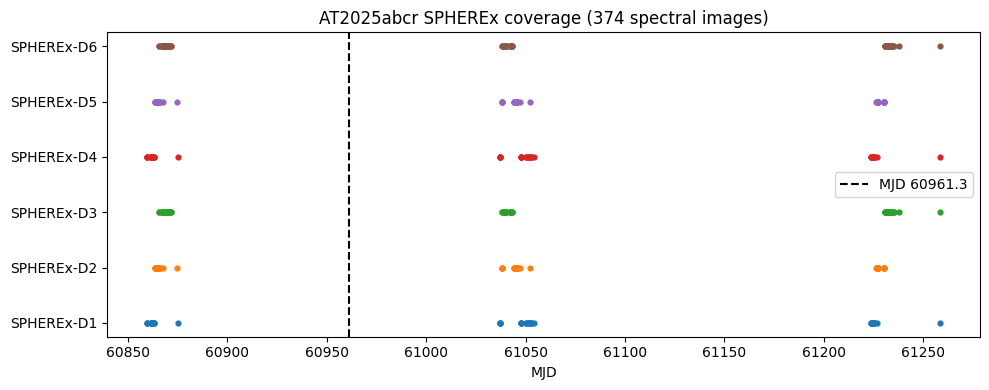

In [5]:
plot_coverage(images, reference_mjd=reference_mjd, title=source);

## Forced photometry

`measure_images` downloads each cutout in parallel and, for every one:

* uses the spatial WCS to find the target's pixel position,
* uses the alternative `W` WCS (a `WAVE-TAB` lookup table in the `WCS-WAVE` extension) to get
  the wavelength and bandwidth that exposure sampled there,
* converts MJy/sr to uJy with the per-detector solid angle pixel map, mapping cutout pixels
  back to the parent frame via `CRPIX1A`/`CRPIX2A`,
* masks pixels flagged in the `FLAGS` bitmap, reading the bit assignments from that extension's
  header rather than assuming them,
* renders the effective PSF for the right detector zone at the source's sub-pixel position, and
  fits its amplitude together with a flat sky by weighted least squares.

That is the method IRSA's Spectrophotometry Tool uses, and it is the right one for a point
source such as a TDE: the source position is held fixed and only the flux is solved for.
Flagged pixels are simply dropped from the fit rather than invalidating the measurement.

Passing `method="aperture"` instead sums fixed apertures of 3, 4 and 5 pixels with a
sigma-clipped 7-16 pixel annulus background, which is preferable only when the target is
genuinely extended. At 6.15 arcsec/pixel an r = 3 pixel aperture is 18.5 arcsec in radius, so
it blends in everything nearby; see `README_spherex_validation.md` for what that costs.

Transient read errors from IRSA are retried, and cutouts are cached, so rerunning is fast.

In [6]:
photometry = measure_images(images, coord)
measured = clean(photometry)
measured.head()

INFO obsutils.spherex.calibration: Loaded solid angle pixel maps for qr2 (cal-sapm-v2-2025-164)


INFO obsutils.spherex.calibration: Loaded solid angle pixel maps for qr3 (cal-sapm-v3-2026-191)


INFO obsutils.spherex.psf: Loaded ePSF for detector 1 (epsf_D1_spx_cal-epsf-v1-2026-191.fits, 441 zones)


INFO obsutils.spherex.psf: Loaded ePSF for detector 2 (epsf_D2_spx_cal-epsf-v1-2026-191.fits, 441 zones)


INFO obsutils.spherex.psf: Loaded ePSF for detector 3 (epsf_D3_spx_cal-epsf-v2-2026-191.fits, 451 zones)


...

INFO obsutils.spherex.psf: Loaded ePSF for detector 6 (epsf_D6_spx_cal-epsf-v1-2026-191.fits, 441 zones)


INFO obsutils.spherex.psf: Loaded ePSF for detector 6 (epsf_D6_spx_cal-epsf-v1-2026-191.fits, 441 zones)


INFO obsutils.spherex.photometry: Measured 374/374 images in 10 s


INFO obsutils.spherex.photometry: 354/374 measurements are usable


,mjd,detector,bandpass,release,phase,wavelength,bandwidth,x,y,n_bad,uri,flux,flux_err,sky,chi2,n_fit_pixels,n_sources,psf_enclosed
0,60859.493998,4,SPHEREx-D4,qr2,pre,3.204890,0.092852,14.331757,13.984767,0.0,ibe/data/spherex/qr2/level2/2025W27_1A/l2b-v20...,958.294078,38.419368,166.715121,58.170184,121,1,1.000000
1,60859.495491,1,SPHEREx-D1,qr2,pre,0.975766,0.025229,13.920568,13.594283,4.0,ibe/data/spherex/qr2/level2/2025W27_1A/l2b-v20...,987.447633,49.828997,321.144066,63.184054,117,1,1.000000
2,60859.495491,4,SPHEREx-D4,qr2,pre,3.292717,0.094987,14.446760,13.999476,3.0,ibe/data/spherex/qr2/level2/2025W27_1A/l2b-v20...,901.725998,38.398564,172.584730,63.702050,118,1,0.999436
3,60859.496983,4,SPHEREx-D4,qr2,pre,3.382029,0.096300,14.086830,13.881447,1.0,ibe/data/spherex/qr2/level2/2025W27_1A/l2b-v20...,821.083458,35.230236,170.120811,55.827397,120,1,1.000000
4,60859.498475,1,SPHEREx-D1,qr2,pre,1.022848,0.027180,14.378031,14.157622,1.0,ibe/data/spherex/qr2/level2/2025W27_1A/l2b-v20...,1412.603185,57.237109,330.083194,65.340608,120,1,1.000000


### Blending: fitting the neighbours at the same time

A single PSF fitted at the target position absorbs any light from sources close enough to share
the PSF. For AT2025abcr the host nucleus is 9.4 arcsec away, which is 1.5 SPHEREx pixels, so
this matters a lot. `find_companions` looks up catalogued sources nearby and `measure_images`
will fit them simultaneously, keeping their light out of the target's amplitude.

Passing companions also tilts the fitted background, which a flat one cannot do for an extended
host. Together that is what `--deblend` turns on from the command line.

In [7]:
companions = find_companions(coord)

joint = measure_images(images, coord, companions=companions)
joint = clean(joint)

print(f"target       {joint['flux'].median():8.0f} uJy")
print(f"nucleus      {joint['flux_companion1'].median():8.0f} uJy "
      f"(correlation with target {joint['corr_companion1'].median():+.2f})")
print(f"single-PSF   {measured['flux'].median():8.0f} uJy, before removing the nucleus")

INFO obsutils.spherex.query: Found 5 companions within 40 arcsec, at 9.4, 16.2, 16.3, 14.7, 23.7 arcsec


INFO obsutils.spherex.photometry: Measured 374/374 images in 11 s


INFO obsutils.spherex.photometry: 354/374 measurements are usable


target            605 uJy
nucleus          4260 uJy (correlation with target -0.13)
single-PSF        947 uJy, before removing the nucleus


Fitting the nucleus removes a few hundred uJy of leakage, and recovers the nucleus at a
brightness consistent with its AllWISE catalogue flux. The correlation between the two
amplitudes is weak, so the fit really does separate them, but what remains at the transient
position is **not** transient flux: with no point source there beforehand, the pre-discovery
amplitude is host galaxy light that no point-source-plus-smooth-sky model removes. Only the
difference between epochs is interpretable.

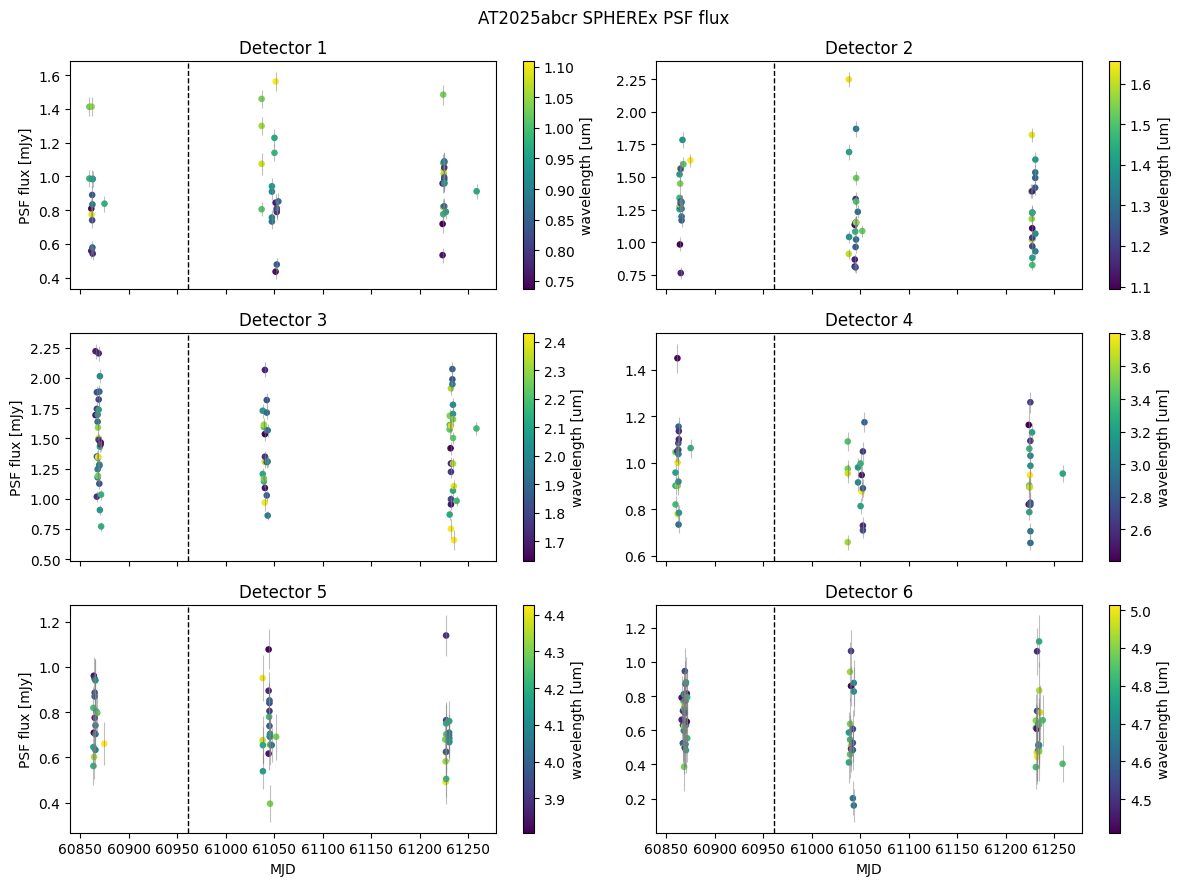

In [8]:
plot_lightcurve(measured, reference_mjd=reference_mjd, title=source);

## Stack into a spectrum

Each exposure samples one wavelength, so the spectrum comes from stacking in wavelength bins:
an inverse-variance weighted mean per bin, computed separately either side of the reference
epoch.

### Getting the error bars right

The propagated errors (VARIANCE extension plus background scatter) turn out to understate how
much the photometry actually varies from epoch to epoch. `error_inflation_factor` measures
this directly: within each bin it removes a straight line in log wavelength, because different
epochs sample different wavelengths across a finite bin and the SED has a real gradient there,
then compares the residuals with the formal errors.

`stack_by_phase` applies the resulting factor by default, so `flux_err` is calibrated against
the data. The raw value is kept as `flux_err_formal`, and `flux_scatter` is an independent
empirical estimate that needs no calibration but is noisy when a bin holds few epochs.

In [9]:
edges = default_wavelength_edges(n_bins=30)

# Keep the single-PSF measurement for the archival comparison below, which is the
# configuration that estimate corresponds to, then use the joint fit for the rest.
single_psf = measured
measured = joint

scale = error_inflation_factor(measured, edges=edges)
print(f"formal errors must be multiplied by {scale:.2f} to match the epoch-to-epoch scatter")

INFO obsutils.spherex.stack: Formal errors understate the epoch scatter by a factor 3.09, from 30 bins


formal errors must be multiplied by 3.09 to match the epoch-to-epoch scatter


In [10]:
stacks = stack_by_block(measured, edges=edges, reference_mjd=reference_mjd)
list(stacks)

INFO obsutils.spherex.stack: Calibrating errors on the pre-reference epochs, where the transient is absent (21 bins)


INFO obsutils.spherex.stack: Formal errors understate the epoch scatter by a factor 2.77, from 21 bins


INFO obsutils.spherex.stack: Stacked 3 blocks: pre (n = 127), post 1 (n = 108), post 2 (n = 118)


['pre', 'post 1', 'post 2']

### Blocks, and whether each is consistent with the baseline

SPHEREx revisits a position once per six-month survey pass, in a burst spanning a few weeks,
and one burst covers the whole wavelength range. So each pass after the reference epoch is its
own complete spectrum, and `stack_by_block` keeps them separate: averaging them would hide a
transient that evolves between passes. Everything before the reference epoch becomes a single
baseline, since the host is constant.

If the flux is host dominated, every block should differ from the baseline only by noise.
`rms(sigma)` is the test: 1 means the variation is exactly what the error bars predict.

### A pre-SPHEREx baseline from archival catalogues

A forced fit picks up every source close enough to share the PSF, so the baseline is rarely
zero. `archival_photometry` sums catalogued sources near the position, each weighted by the
fraction of its flux a fit centred on the target would pick up, computed from the real ePSF
rather than a Gaussian. That gives an independent estimate of the pre-SPHEREx level from data
taken years before launch, which the SED plot overlays as "estimated from archival photometry".

Extended sources need their extended photometry. A galaxy is in the point-source catalogues
too, but only its core is: the 2MASS point-source entry for this host is 4.1 mJy at Ks against
10.5 mJy for the whole galaxy. `archival_photometry` queries the 2MASS extended source
catalogue as well and uses the WISE elliptical aperture magnitudes where WISE flags a source as
extended. Pan-STARRS is off by default, because neither of its magnitudes works for a galaxy.

Compare the overlay with the **single-PSF** measurement, `measured`, rather than the joint fit:
it is the total catalogued flux in the PSF, and the joint fit has deliberately removed the
companions from that.

In [11]:
archival = archival_photometry(coord)

single = stack_by_block(single_psf, edges=edges)["pre"]
for _, row in archival.iterrows():
    i = (single["wavelength"] - row["wavelength"]).abs().idxmin()
    print(f"{row['band']:>9} {row['wavelength']:5.2f} um   "
          f"archival {row['flux'] / 1e3:5.2f} mJy   "
          f"SPHEREx {single['flux'][i] / 1e3:5.2f} mJy   "
          f"ratio {row['flux'] / single['flux'][i]:5.2f}")

INFO obsutils.spherex.archival: 1 2MASS point source(s) replaced by their extended-source photometry


INFO obsutils.spherex.archival: 3 WISE source(s) using elliptical aperture magnitudes


INFO obsutils.spherex.archival: Archival estimate in 5 bands, 0.68 to 1.78 mJy


INFO obsutils.spherex.stack: Calibrating errors on the pre-reference epochs, where the transient is absent (21 bins)


INFO obsutils.spherex.stack: Formal errors understate the epoch scatter by a factor 2.91, from 21 bins


INFO obsutils.spherex.stack: Stacked 3 blocks: pre (n = 127), post 1 (n = 108), post 2 (n = 118)


  2MASS J  1.24 um   archival  1.75 mJy   SPHEREx  1.38 mJy   ratio  1.26
  2MASS H  1.66 um   archival  1.78 mJy   SPHEREx  1.64 mJy   ratio  1.08
 2MASS Ks  2.16 um   archival  1.46 mJy   SPHEREx  1.13 mJy   ratio  1.29
  WISE W1  3.35 um   archival  1.12 mJy   SPHEREx  0.92 mJy   ratio  1.22
  WISE W2  4.60 um   archival  0.68 mJy   SPHEREx  0.67 mJy   ratio  1.02


INFO obsutils.spherex.stack: post 1: rms(sigma) = 1.35 over 30 bins


INFO obsutils.spherex.stack: post 2: rms(sigma) = 1.78 over 30 bins


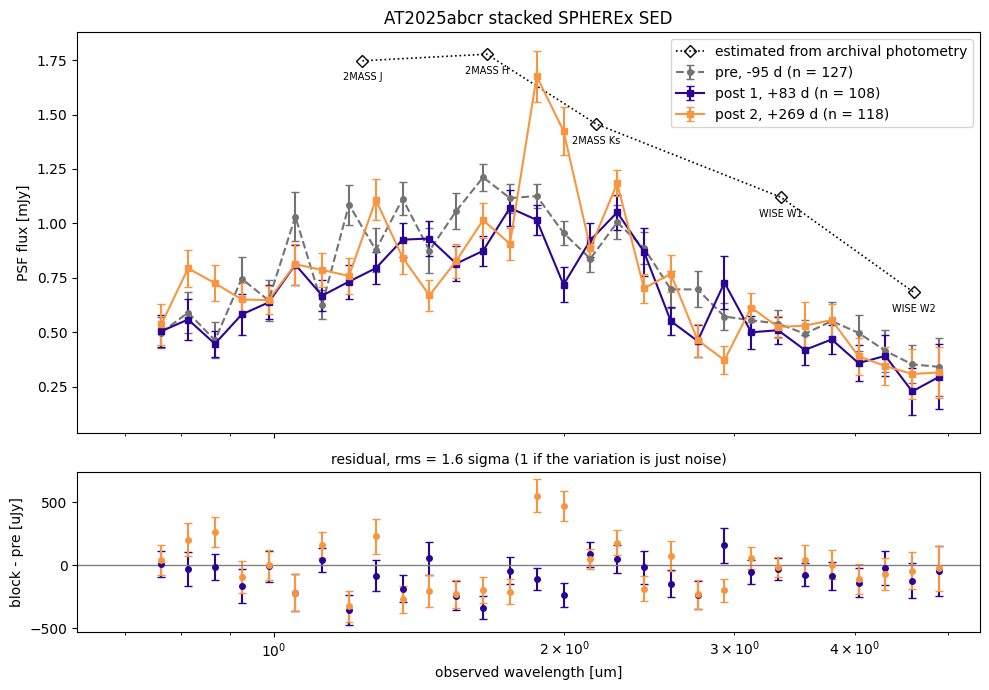

In [12]:
difference = difference_stacks(stacks)

plot_sed(stacks, title=source, difference=difference, archival=archival);

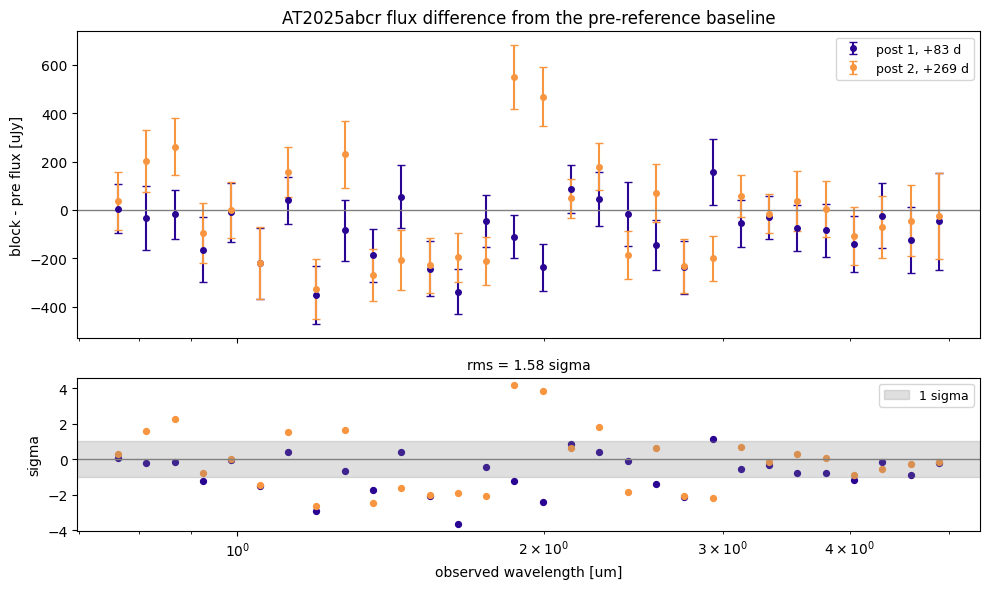

In [13]:
plot_difference(difference, title=source);

In [14]:
# The stacks keep the uncalibrated errors too, so the same test can be run
# without the calibration.
pre, post = stacks["pre"], stacks["post 1"]
raw = np.hypot(pre["flux_err_formal"], post["flux_err_formal"])
raw_sigma = (post["flux"] - pre["flux"]) / raw

first = difference[difference["block"] == "post 1"]
print(f"calibrated errors: rms = {np.sqrt(np.mean(first['sigma'] ** 2)):.2f} sigma")
print(f"    formal errors: rms = {np.sqrt(np.mean(raw_sigma ** 2)):.2f} sigma")

calibrated errors: rms = 1.35 sigma
    formal errors: rms = 3.74 sigma


In [15]:
# One line per block: its net offset from the baseline, averaged over wavelength.
from obsutils.spherex.pipeline import block_summary

block_summary(difference)

,block,phase_days,bins,offset_uJy,offset_err,sigma,rms_sigma
0,post 1,82.8,30,-90.9,20.3,-4.5,1.35
1,post 2,268.8,30,-18.0,20.3,-0.9,1.78


### Is the difference real, or is the blend just being split differently?

Because the target and the nucleus share a PSF, the fit can move flux between them from epoch
to epoch without either actually varying. The test is to apply the same stacking to the
companion amplitudes, which come out of the very same fits. A real change at the transient
position should leave the companions alone.

In [16]:
def stacked_offset(flux_col, err_col):
    """Weighted mean post - pre offset for one fitted component."""
    rows = []
    index = np.digitize(measured["wavelength"], edges) - 1
    for b in range(len(edges) - 1):
        sel = measured[index == b]
        pre, post = sel[sel["phase"] == "pre"], sel[sel["phase"] == "post"]
        if (len(pre) < 2) | (len(post) < 2):
            continue
        mean = lambda t: (
            np.sum(t[flux_col] / t[err_col] ** 2) / np.sum(1 / t[err_col] ** 2),
            1 / np.sqrt(np.sum(1 / t[err_col] ** 2)),
        )
        a, ae = mean(pre)
        b_, be = mean(post)
        rows.append((b_ - a, np.hypot(ae, be)))
    arr = np.array(rows)
    w = 1 / arr[:, 1] ** 2
    return np.sum(arr[:, 0] * w) / np.sum(w), 1 / np.sqrt(np.sum(w))

for label, fcol, ecol in [
    ("TDE position (off-nuclear)", "flux", "flux_err"),
    ("host nucleus, 9.4 arcsec", "flux_companion1", "flux_err_companion1"),
    ("neighbour, 16.2 arcsec", "flux_companion2", "flux_err_companion2"),
]:
    value, err = stacked_offset(fcol, ecol)
    print(f"{label:<28} {value:+7.0f} +- {err * scale:5.0f} uJy")

TDE position (off-nuclear)       -60 +-    19 uJy
host nucleus, 9.4 arcsec         +41 +-    34 uJy
neighbour, 16.2 arcsec           +13 +-    31 uJy


The transient position and the nucleus move by similar amounts in opposite directions, while
the more distant neighbour does not move at all. That is flux being partitioned differently
between two blended components, not either of them varying, and their sum is nearly unchanged.
So the apparent offset at the transient position is a systematic floor, not a measurement of
the TDE.

## The same thing in one call

`run_photometry` does everything above and returns the tables. Output always goes to
`$OUTPUT_DIR/<name>/spherex/`, with `OUTPUT_DIR` read from `.env`. From the command line the same run is:

```
spherex-phot AT2025abcr --reference-mjd 60961.28 --deblend --plot
```

In [17]:
from obsutils.spherex import run_photometry, save_plots

result = run_photometry(source, reference_mjd=reference_mjd, deblend=True)
save_plots(result)

print(result.output_dir)
result.difference.round({"wavelength": 2, "diff": 1, "diff_err": 1, "sigma": 1}).head()

INFO obsutils.spherex.query: Resolved AT2025abcr to 01h46m55.3999992s -15d22m15.710016s


INFO obsutils.spherex.query: Found 374 SPHEREx images, MJD 60859.5 to 61258.6


INFO obsutils.spherex.query: Found 5 companions within 40 arcsec, at 9.4, 16.2, 16.3, 14.7, 23.7 arcsec


INFO obsutils.spherex.photometry: Measured 374/374 images in 11 s


INFO obsutils.spherex.photometry: 354/374 measurements are usable


...

INFO obsutils.spherex.archival: Archival estimate in 5 bands, 0.68 to 1.78 mJy


INFO obsutils.spherex.pipeline: Wrote SPHEREx products to /Users/rdstein/Data/obsutils/AT2025abcr/spherex


INFO obsutils.spherex.pipeline: Wrote SPHEREx plots to /Users/rdstein/Data/obsutils/AT2025abcr/spherex


/Users/rdstein/Data/obsutils/AT2025abcr/spherex


,block,phase_days,wavelength,n_pre,n_post,flux_pre,flux_post,diff,diff_err,sigma
0,post 1,82.798756,0.76,3,3,499.176966,505.142534,6.0,103.1,0.1
1,post 1,82.798756,0.81,2,2,590.741213,558.969190,-31.8,132.8,-0.2
2,post 1,82.798756,0.87,2,4,464.108597,447.481687,-16.6,101.3,-0.2
3,post 1,82.798756,0.93,2,2,746.518244,582.183407,-164.3,135.4,-1.2
4,post 1,82.798756,0.99,2,3,646.858254,637.199644,-9.7,122.9,-0.1


## Caveats

* **AT2025abcr is off-nuclear, and SPHEREx cannot cleanly resolve it from its host.** The
  nucleus is 9.4 arcsec away, 1.5 pixels, against a PSF FWHM of 5-10 arcsec. Fitting the nucleus
  as a companion removes a few hundred uJy of leakage from the transient position, and the two
  amplitudes are only weakly correlated, but the separation is never clean.
* **The flux at the transient position is not transient flux.** There was no point source there
  before discovery, yet the fit returns several hundred uJy in the pre-discovery stack. That is
  extended host light: a point source plus a flat or tilted sky cannot describe a galaxy at this
  pixel scale. The tilted background that `deblend` turns on reduces the absolute level but
  never to zero.
* **Only differences are interpretable, and even they have a floor here.** The post minus pre
  offset at the transient position is about -55 uJy, while the nucleus moves by about +40 uJy
  and the distant neighbour not at all. Two blended components swapping flux, not varying. Treat
  roughly 50 uJy as the systematic floor for this target, and read no TDE detection from it.
* **Errors understate the epoch scatter**, by about a factor 3 for the joint fit. The stacks
  rescale by the measured factor, after which the phases agree at rms = 1.4 sigma. The factor is
  measured on the pre-reference epochs, where the transient is absent: measured over all epochs
  a genuinely variable source has its own variability counted as noise. On the bright nova used
  to test this, that difference is a factor of 17 against 4, and suppresses a real 52 sigma
  detection to 3 sigma. See `README_spherex_validation.md`.
* **The archival overlay is an estimate.** Against the single-PSF photometry here it agrees to
  2-29% across 1.2 to 4.6 um. In a crowded field it does much worse: for the nova used to test
  the pipeline it over-predicts by a factor of two in the near-infrared and by ten or more in
  the mid-infrared, where the fitted sky term absorbs the stellar confusion background that the
  catalogue sum counts as source flux. It is also not comparable to a joint fit, which has
  removed companions the estimate still includes.
* **Coverage is bursty.** SPHEREx visits a field in groups of epochs, so the pre- and
  post-reference stacks do not sample wavelength uniformly, and the first post-discovery epochs
  here are already 76 days after discovery.
* **Zodiacal light is not subtracted** from the `IMAGE` extension; the fitted sky absorbs it.
  The `ZODI` extension holds the model if an explicit subtraction is wanted.
* **This is not identical to IRSA's tool.** Against published forced-PSF spectrophotometry of
  three Galactic transients, matched exposure by exposure, the fluxes here agree to a median
  ratio of 1.047 with 12% per-exposure scatter, and the errors to 3%; see
  `README_spherex_validation.md`. For publication-grade absolute fluxes, use IRSA's tool.
* New data are ingested weekly, so rerunning later picks up additional epochs.